# PyTorch ImageFolder (Inbuilt) + Training Pipeline


In [1]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image

import time
import shutil
import random
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision import transforms, datasets

import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(RAW_DIR, dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

In [3]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [4]:
imagefolder_dataset = datasets.ImageFolder(
    root=RAW_DIR, 
    transform=custom_transform
)

In [5]:
print(f"Classes found by ImageFolder: {imagefolder_dataset.classes}")
print(f"Class to index mapping: {imagefolder_dataset.class_to_idx}")

Classes found by ImageFolder: ['class_0_non_agri', 'class_1_agri']
Class to index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


In [6]:
BATCH_SIZE = 8 

imagefolder_loader = DataLoader(
    imagefolder_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


On Windows, Jupyter can't spawn background worker processes, so num_workers=2 causes everything to freeze indefinitely.

In [7]:
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))

print(f"Images batch shape (PyTorch in-built loader): {images_inbuilt.shape}") 
print(f"Labels batch shape (PyTorch in-built loader): {labels_inbuilt.shape}")

Images batch shape (PyTorch in-built loader): torch.Size([8, 3, 64, 64])
Labels batch shape (PyTorch in-built loader): torch.Size([8])


In [8]:
def imshow(img):
    img = img.detach().cpu()
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Convert from C,H,W to H,W,C

The .detach().cpu() is still a good practice to keep — it explicitly tells PyTorch "don't track gradients, make sure this is on CPU" before converting to numpy. Safer to have it.

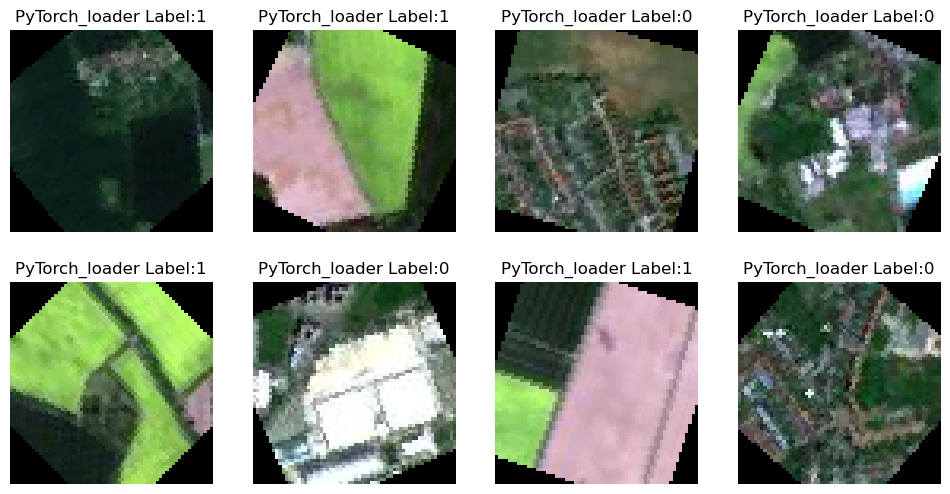

In [9]:
plt.figure(figsize = (12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_inbuilt[i])
    plt.title(f"PyTorch_loader Label:{labels_inbuilt[i].item()}")
    plt.axis("off")  
plt.show()

In [10]:
def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch (CPU & all GPUs) and
    make cuDNN run in deterministic mode."""
    # ---- Python and NumPy -------------------------------------------
    random.seed(seed)
    np.random.seed(seed)

    # ---- PyTorch (CPU  &  GPU) --------------------------------------
    torch.manual_seed(seed)            
    torch.cuda.manual_seed_all(seed)   

    # ---- cuDNN: force repeatable convolutions -----------------------
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark     = False 

In [11]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} — main process is now deterministic.")

Global seed set to 42 — main process is now deterministic.


In [12]:
def worker_init_fn(worker_id: int) -> None:
    """Re-seed each DataLoader worker so their RNGs don't collide."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed) 
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

Only relevant when num_workers > 0.
With num_workers = 0, DataLoader runs in the main process,
so no separate worker seeds are needed.

In [13]:
(RAW_DIR, dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

In [14]:
dataset_path = os.path.join(RAW_DIR)
print(dataset_path)

..\data\raw\images_dataSAT


In [15]:
img_size = 64
batch_size = 128
lr = 0.001
epochs = 15
model_name = "best_model.pytorch_inbuilt.h5"
num_classes = 2

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used is {device}")

Device used is cuda


In [16]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(40),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(0, shear=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [17]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [18]:
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

In [19]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

In [20]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    worker_init_fn=worker_init_fn
)

In [21]:
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn
)

In [22]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
    nn.MaxPool2d(2), nn.BatchNorm2d(32),
                        
    nn.Conv2d(32, 64, 5, padding=2), 
    nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
    nn.Conv2d(64, 128, 5, padding=2), 
    nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
    nn.Conv2d(128, 256, 5, padding=2), 
    nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
    nn.Conv2d(256, 512, 5, padding=2), 
    nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
    nn.Conv2d(512, 1024, 5, padding=2), 
    nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024),
                        
    nn.AdaptiveAvgPool2d(1), 
    nn.Flatten(),
    nn.Linear(1024, 2048), 
    nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
    nn.Linear(2048, num_classes)
).to(device)

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
best_loss = float('inf')
loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}


In [24]:
print(f"Training on : -----{device}----- with batch size: {batch_size} & lr: {lr}")

for epoch in range(epochs):
    start_time = time.time() # to get the training time for each epoch
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0  # for the training metrics
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
        images, labels = images.to(device), labels.to(device)  # labels as integer class indices
        optimizer.zero_grad()
        outputs = model(images)  # outputs are raw logits
        loss = criterion(outputs, labels)  # criterion is nn.CrossEntropyLoss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
  
    # Synchronize CUDA before stopping timer (if using GPU)
    if device == 'cuda':
        torch.cuda.synchronize()

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0 #  for the validation metrics
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
  
    # Save the best model
    avg_val_loss = val_loss/len(val_loader)
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), model_name)
    
    # Store metrics
    loss_history['train'].append(train_loss/len(train_loader))
    loss_history['val'].append(val_loss/len(val_loader))
    acc_history['train'].append(train_correct/train_total)
    acc_history['val'].append(val_correct/val_total)
    
    #print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {loss_history['train'][-1]:.4f} | Val Loss: {loss_history['val'][-1]:.4f}")
    print(f"Train Acc: {acc_history['train'][-1]:.4f} | Val Acc: {acc_history['val'][-1]:.4f}")
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} training completed in {epoch_time:.2f} seconds\n") 



Training on : -----cuda----- with batch size: 128 & lr: 0.001


Epoch 1/15: 100%|██████████████████████████████████████████████████████████████████████| 38/38 [00:12<00:00,  3.02it/s]


Train Loss: 0.2630 | Val Loss: 0.0224
Train Acc: 0.9354 | Val Acc: 0.9925
Epoch 1 training completed in 15.39 seconds



Epoch 2/15: 100%|██████████████████████████████████████████████████████████████████████| 38/38 [00:08<00:00,  4.63it/s]


Train Loss: 0.0176 | Val Loss: 0.0164
Train Acc: 0.9931 | Val Acc: 0.9933
Epoch 2 training completed in 10.03 seconds



...

Train Loss: 0.0021 | Val Loss: 0.0141
Train Acc: 0.9996 | Val Acc: 0.9933
Epoch 13 training completed in 9.45 seconds



Epoch 14/15: 100%|█████████████████████████████████████████████████████████████████████| 38/38 [00:07<00:00,  4.82it/s]


Train Loss: 0.0110 | Val Loss: 0.0089
Train Acc: 0.9971 | Val Acc: 0.9975
Epoch 14 training completed in 9.44 seconds



Epoch 15/15: 100%|█████████████████████████████████████████████████████████████████████| 38/38 [00:07<00:00,  4.91it/s]


Train Loss: 0.0098 | Val Loss: 0.0118
Train Acc: 0.9975 | Val Acc: 0.9967
Epoch 15 training completed in 9.38 seconds



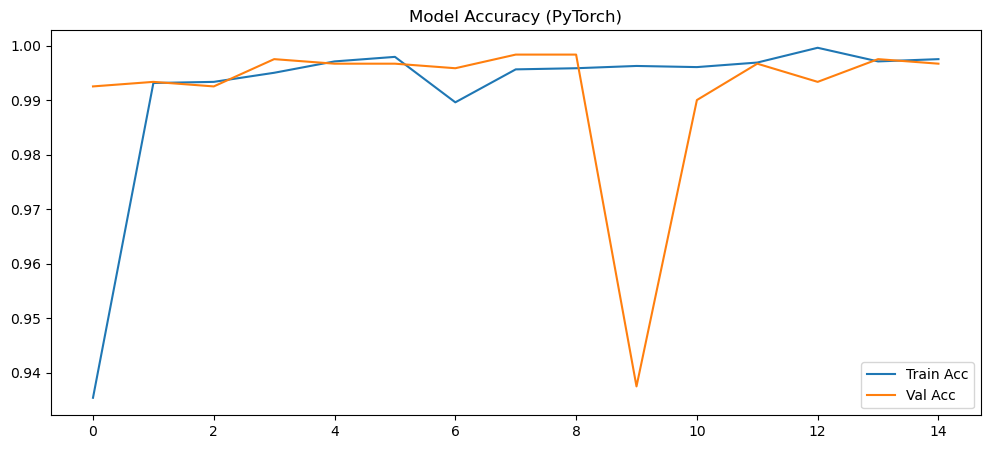

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(acc_history['train'], label='Train Acc')
plt.plot(acc_history['val'], label='Val Acc')
plt.title('Model Accuracy (PyTorch)')
plt.legend()
plt.show()

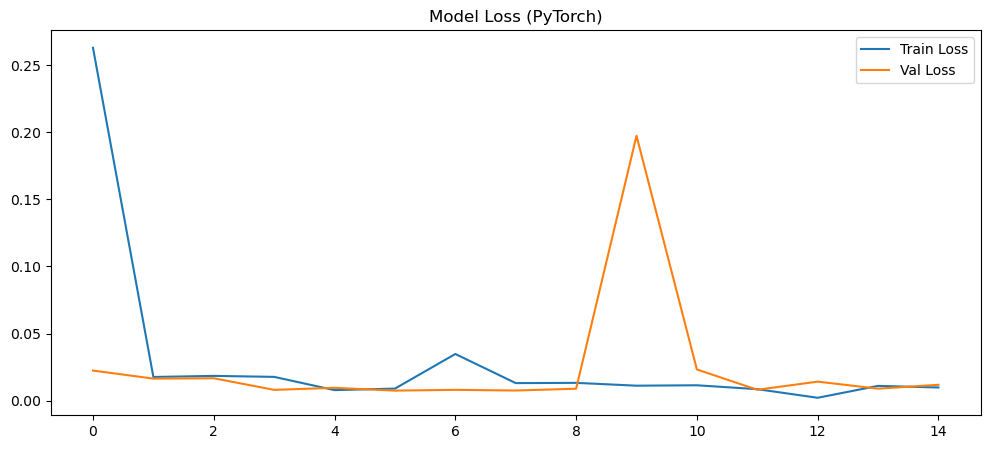

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(loss_history['train'], label='Train Loss')
plt.plot(loss_history['val'], label='Val Loss')
plt.title('Model Loss (PyTorch)')
plt.legend()
plt.show()

In [27]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())

In [28]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"The accuracy of the model is: {accuracy:.4f}")

The accuracy of the model is: 0.9967
